### prep chai array-like

In [ ]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/germinal_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  "/home/bri/pymol/EDA/static/germinal_outputs/merged_germinal.csv"
scores_df = pd.read_csv(CSV_PATH)

scores_df.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347,"[[0.9273825883865356, 0.8894672989845276]]","[[[0.9273825883865356, 0.44341152906417847], [...","[[0.9388881325721741, 0.9319360852241516]]","[[[0.9388881325721741, 0.806764543056488], [0...."
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713,"[[0.9228965044021606, 0.8899376392364502]]","[[[0.9228965044021606, 0.6508838534355164], [0...","[[0.9284995794296265, 0.9254387021064758]]","[[[0.9284995794296265, 0.6832306385040283], [0..."
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039,"[[0.9310107827186584, 0.926919162273407]]","[[[0.9310107827186584, 0.7188717126846313], [0...","[[0.9230786561965942, 0.8749508857727051]]","[[[0.9230786561965942, 0.3063301742076874], [0..."
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998,"[[0.9071958065032959, 0.8811732530593872]]","[[[0.9071958065032959, 0.6785235404968262], [0...","[[0.8953481316566467, 0.9284237623214722]]","[[[0.8953481316566467, 0.7335245609283447], [0..."
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743,"[[0.8962238430976868, 0.884861171245575]]","[[[0.8962238430976868, 0.26031896471977234], [...","[[0.9198889136314392, 0.8923708200454712]]","[[[0.9198889136314392, 0.3899534344673157], [0..."


### prep chai array-like

In [16]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)

In [17]:
chai_df.head()

,sample,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,nb_s413501_mpnn_3_PDL1,"[[0.9273825883865356, 0.8894672989845276]]","[[[0.9273825883865356, 0.44341152906417847], [...","[[0.9388881325721741, 0.9319360852241516]]","[[[0.9388881325721741, 0.806764543056488], [0...."
1,nb_s80903_mpnn_4_PDL1,"[[0.9228965044021606, 0.8899376392364502]]","[[[0.9228965044021606, 0.6508838534355164], [0...","[[0.9284995794296265, 0.9254387021064758]]","[[[0.9284995794296265, 0.6832306385040283], [0..."
2,nb_s185784_mpnn_4_PDL1,"[[0.9310107827186584, 0.926919162273407]]","[[[0.9310107827186584, 0.7188717126846313], [0...","[[0.9230786561965942, 0.8749508857727051]]","[[[0.9230786561965942, 0.3063301742076874], [0..."
3,nb_s465730_mpnn_4_PDL1,"[[0.9071958065032959, 0.8811732530593872]]","[[[0.9071958065032959, 0.6785235404968262], [0...","[[0.8953481316566467, 0.9284237623214722]]","[[[0.8953481316566467, 0.7335245609283447], [0..."
4,nb_s892360_mpnn_4_PDL1,"[[0.8962238430976868, 0.884861171245575]]","[[[0.8962238430976868, 0.26031896471977234], [...","[[0.9198889136314392, 0.8923708200454712]]","[[[0.9198889136314392, 0.3899534344673157], [0..."


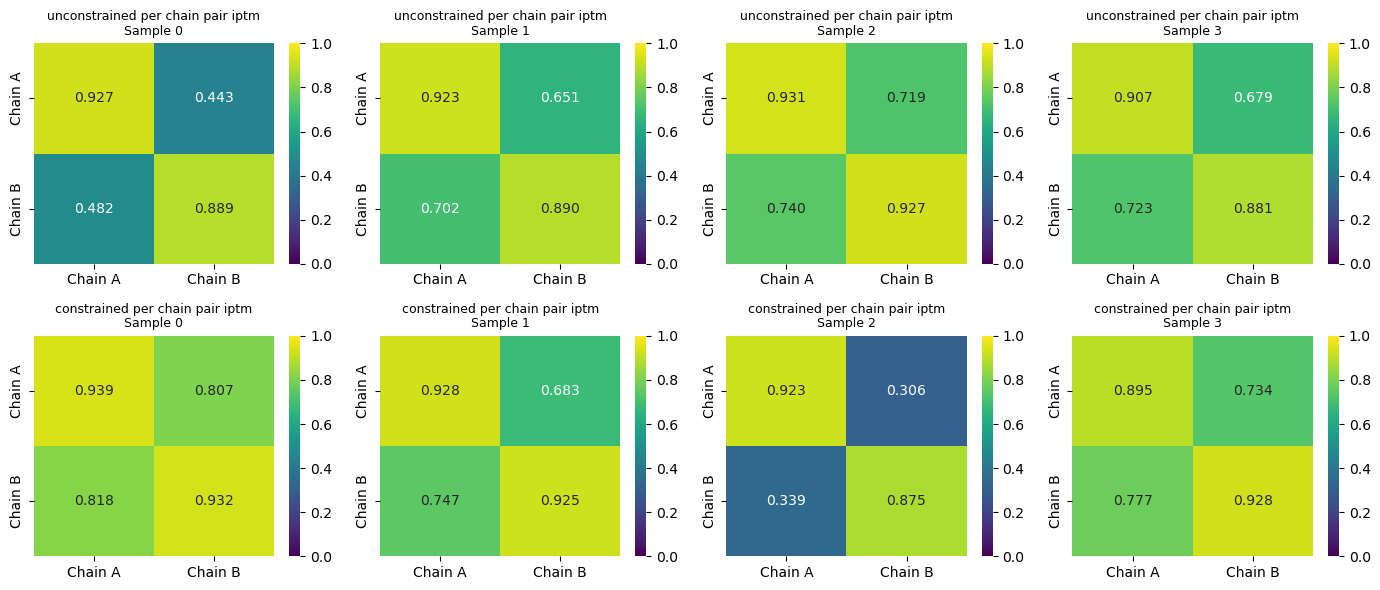

In [18]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [19]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # constrained: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # unconstrained: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.443412
1    0.650884
2    0.718872
3    0.678524
4    0.254212
5    0.259963
6    0.236120
7    0.379382
8    0.804686
9    0.532868

Constrained A-B interface min (top 10):
0    0.806765
1    0.683231
2    0.306330
3    0.733525
4    0.389953
5    0.685075
6    0.584192
7    0.682946
8    0.430920
9    0.436881


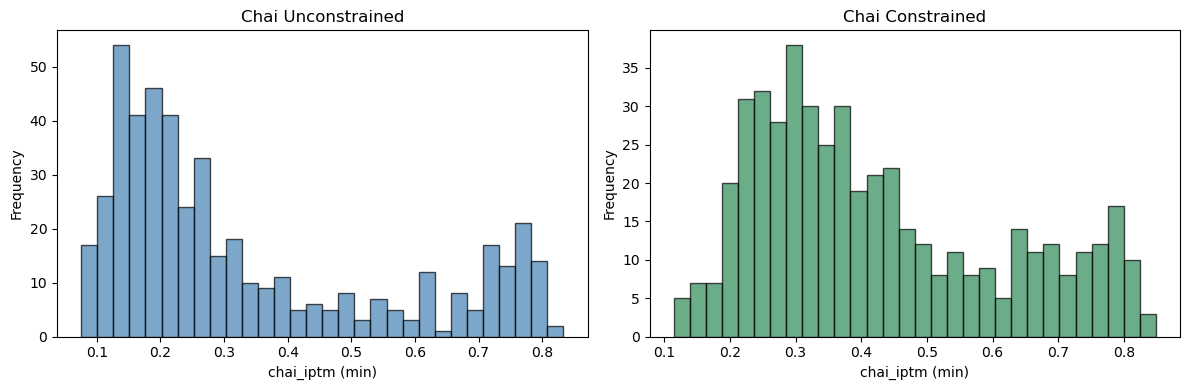

In [20]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Extract mean pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract mean for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract mean for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.889467
1    0.889938
2    0.926919
3    0.881173
4    0.884861
5    0.877490
6    0.860806
7    0.886451
8    0.924071
9    0.893817

Constrained pTM min (top 10):
0    0.931936
1    0.925439
2    0.874951
3    0.895348
4    0.892371
5    0.924141
6    0.896732
7    0.896484
8    0.886043
9    0.854385

Unconstrained pTM min - desc stats:
count    480.000000
mean       0.768292
std        0.238117
min        0.296807
25%        0.860612
50%        0.884581
75%        0.898857
max        0.932477
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    480.000000
mean       0.773300
std        0.223717
min        0.302077
25%        0.851541
50%        0.882924
75%        0.900171
max        0.933283
Name: chai_constrained_per_chain_ptm, dtype: float64


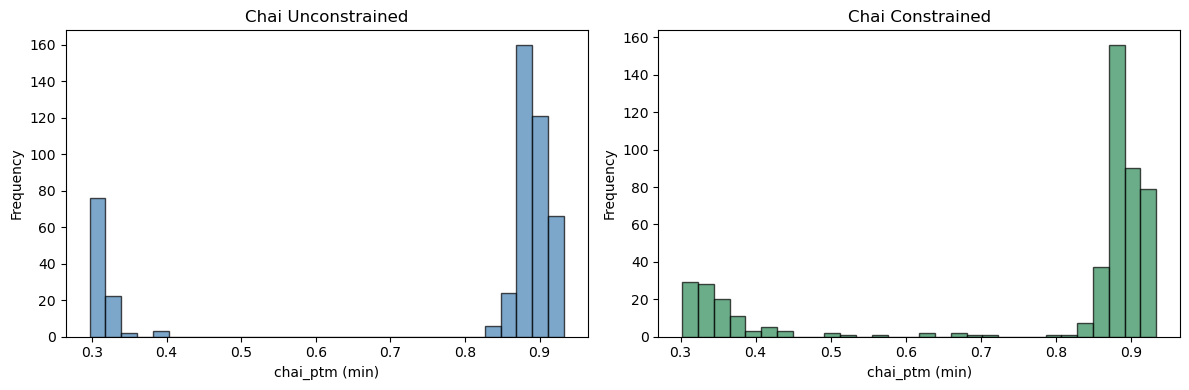

In [22]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_iptm',
                            'chai_constrained_per_chain_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (480, 5)

df_chai_numeric head:
                   sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0  nb_s413501_mpnn_3_PDL1                          0.889467                        0.931936                           0.443412                         0.806765
1   nb_s80903_mpnn_4_PDL1                          0.889938                        0.925439                           0.650884                         0.683231
2  nb_s185784_mpnn_4_PDL1                          0.926919                        0.874951                           0.718872                         0.306330
3  nb_s465730_mpnn_4_PDL1                          0.881173                        0.895348                           0.678524                         0.733525
4  nb_s892360_mpnn_4_PDL1                          0.884861                        0.892371                           0.254212                   

In [24]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,0.639892,0.935969,0.913586,0.558209,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,0.843225,0.901484,0.861739,0.433091,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,0.688911,0.865942,0.825091,0.601709,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,0.845215,0.907688,0.875164,0.419413,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,0.906872,0.931934,0.914226,0.367888,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743


In [25]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (480, 90)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm']

scores_df_extended head:
                   sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0  nb_s413501_mpnn_3_PDL1                          0.889467                        0.931936                           0.443412                         0.806765
1   nb_s80903_mpnn_4_PDL1                          0.889938                        0.925439                           0.650884                         0.683231
2  nb_s185784_mpnn_4_PDL1                          0.926919                        0.874951                           0.718872                         0.306330
3  nb_s465730_mpnn_4_PDL1                          0.881173                        0.895348                         

In [26]:
scores_df_extended.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347,0.889467,0.931936,0.443412,0.806765
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713,0.889938,0.925439,0.650884,0.683231
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039,0.926919,0.874951,0.718872,0.306330
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998,0.881173,0.895348,0.678524,0.733525
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743,0.884861,0.892371,0.254212,0.389953
